<a href="https://colab.research.google.com/github/varaiitj2527/PRMLProject/blob/main/Model/Clustering_Models/Gaussian_Mixture_Models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
!git clone https://github.com/varaiitj2527/PRMLProject.git
%cd PRMLProject

Cloning into 'PRMLProject'...
remote: Enumerating objects: 58, done.
remote: Counting objects: 100% (40/40), done.
remote: Compressing objects: 100% (36/36), done.
remote: Total 58 (delta 8), reused 15 (delta 0), pack-reused 18 (from 2)
Receiving objects: 100% (58/58), 163.32 MiB | 21.13 MiB/s, done.
Resolving deltas: 100% (8/8), done.
Updating files: 100% (27/27), done.
Filtering content: 100% (12/12), 851.90 MiB | 36.42 MiB/s, done.
/content/PRMLProject/PRMLProject/PRMLProject


In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score
from tqdm import tqdm
import pickle

In [19]:
def unpickle(file):   # Function for unpickling the file
    with open(file, 'rb') as f:
        return pickle.load(f)

# Gaussian Mixture Model with PCA


In [20]:
X_train_gmm_pca=unpickle("PreProcessedData/TrainFeaturesPCA.pkl")
print(X_train_gmm_pca.shape)
y_train=unpickle("PreProcessedData/Labels_train.pkl")
print(y_train.shape)
X_test_gmm_pca=unpickle("PreProcessedData/TestFeaturesPCA.pkl")
y_test=unpickle("PreProcessedData/Labels_test.pkl")

(50000, 658)
(50000,)


In [21]:
from sklearn.mixture import GaussianMixture    # Using Gaussian Mixture Model
num_classes = 10  # There are 10 classes
gmms = []

for i in range(num_classes):
    X_train_gmm_pca_class = X_train_gmm_pca[y_train == i]  # Select images of class i
    gmm = GaussianMixture(n_components=5, covariance_type='full', random_state=42)  # Use 5 Gaussian components per class
    gmm.fit(X_train_gmm_pca_class)
    gmms.append(gmm)

In [22]:
y_gmm_pca_pred = []
for x in X_test_gmm_pca:
    scores = [gmm.score_samples(x.reshape(1, -1)) for gmm in gmms]   # Compute likelihood for each class
    y_gmm_pca_pred.append(np.argmax(scores))    # Assign class with highest probability

In [23]:
accuracy = accuracy_score(y_test, y_gmm_pca_pred)  # Accuracy score
print(f"Test Accuracy: {accuracy:.4f}")

Test Accuracy: 0.3910


Text(0.5, 1.0, 'Confusion Matrix')

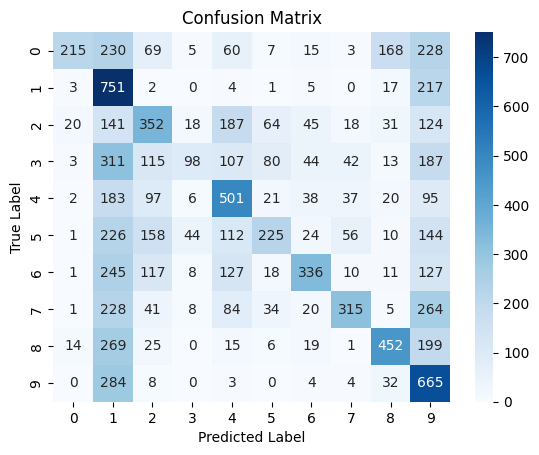

In [24]:
from sklearn.metrics import confusion_matrix   # Plotting confusion matrix
cm = confusion_matrix(y_test, y_gmm_pca_pred)
sns.heatmap(cm,annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

# Gaussian Mixture Model with HoG

In [25]:
X_train_gmm_hog=unpickle("PreProcessedData/TrainFeaturesHoG.pkl")
print(X_train_gmm_hog.shape)
y_train=unpickle("PreProcessedData/Labels_train.pkl")
print(y_train.shape)
X_test_gmm_hog=unpickle("PreProcessedData/TestFeaturesHoG.pkl")
y_test=unpickle("PreProcessedData/Labels_test.pkl")

(50000, 324)
(50000,)


In [26]:
from sklearn.mixture import GaussianMixture    # Using Gaussian Mixture Model
num_classes = 10  # There are 10 classes
gmms = []

for i in range(num_classes):
    X_train_gmm_hog_class = X_train_gmm_hog[y_train == i]  # Select images of class i
    gmm = GaussianMixture(n_components=5, covariance_type='full', random_state=42)  # Use 5 Gaussian components per class
    gmm.fit(X_train_gmm_hog_class)
    gmms.append(gmm)

In [27]:
y_gmm_hog_pred = []
for x in X_test_gmm_hog:
    scores = [gmm.score_samples(x.reshape(1, -1)) for gmm in gmms]   # Compute likelihood for each class
    y_gmm_hog_pred.append(np.argmax(scores))    # Assign class with highest probability

In [28]:
accuracy = accuracy_score(y_test, y_gmm_hog_pred)  # Accuracy score
print(f"Test Accuracy: {accuracy:.4f}")

Test Accuracy: 0.4633


Text(0.5, 1.0, 'Confusion Matrix')

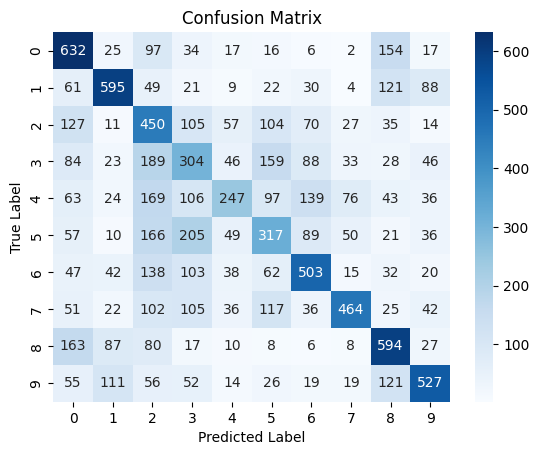

In [29]:
from sklearn.metrics import confusion_matrix   # Plotting confusion matrix
cm = confusion_matrix(y_test, y_gmm_hog_pred)
sns.heatmap(cm,annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

# Gausian Mixture Model with HoG + PCA

In [30]:
X_train_gmm_hog_pca=unpickle("PreProcessedData/TrainFeaturesHoG_PCA.pkl")
print(X_train_gmm_hog_pca.shape)
y_train=unpickle("PreProcessedData/Labels_train.pkl")
print(y_train.shape)
X_test_gmm_hog_pca=unpickle("PreProcessedData/TestFeaturesHoG_PCA.pkl")
y_test=unpickle("PreProcessedData/Labels_test.pkl")

(50000, 170)
(50000,)


In [31]:
from sklearn.mixture import GaussianMixture  # Importing GMM
num_classes = 10    # There are 10 classes
gmms = []

for i in range(num_classes):
    X_train_gmm_hog_pca_class = X_train_gmm_hog_pca[y_train == i]    # Select images of class i
    gmm = GaussianMixture(n_components=5, covariance_type='full', random_state=42)  # Use 5 Gaussian components per class
    gmm.fit(X_train_gmm_hog_pca_class)
    gmms.append(gmm)

In [32]:
y_gmm_hog_pca_pred = []
for x in X_test_gmm_hog_pca:
    scores = [gmm.score_samples(x.reshape(1, -1)) for gmm in gmms]    # Compute likelihood for each class
    y_gmm_hog_pca_pred.append(np.argmax(scores))   # Assign class with highest probability

In [33]:
accuracy = accuracy_score(y_test, y_gmm_hog_pca_pred)   # Finding accuracy scores
print(f"Test Accuracy: {accuracy:.4f}")

Test Accuracy: 0.5424


Text(0.5, 1.0, 'Confusion Matrix')

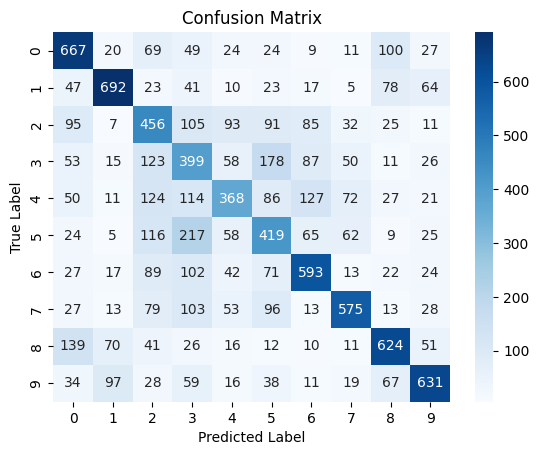

In [34]:
from sklearn.metrics import confusion_matrix       # Confusion matrix
cm = confusion_matrix(y_test, y_gmm_hog_pca_pred)
sns.heatmap(cm,annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

# Gaussian Mixture Model with PCA + HoG

In [35]:
X_train_gmm_pca_hog=unpickle("PreProcessedData/TrainFeaturesPCA_HoG.pkl")
print(X_train_gmm_pca_hog.shape)
y_train=unpickle("PreProcessedData/Labels_train.pkl")
print(y_train.shape)
X_test_gmm_pca_hog=unpickle("PreProcessedData/TestFeaturesPCA_HoG.pkl")
y_test=unpickle("PreProcessedData/Labels_test.pkl")

(50000, 324)
(50000,)


In [36]:
from sklearn.mixture import GaussianMixture  # Importing GMM
num_classes = 10    # There are 10 classes
gmms = []

for i in range(num_classes):
    X_train_gmm_pca_hog_class = X_train_gmm_pca_hog[y_train == i]    # Select images of class i
    gmm = GaussianMixture(n_components=5, covariance_type='full', random_state=42)  # Use 5 Gaussian components per class
    gmm.fit(X_train_gmm_pca_hog_class)
    gmms.append(gmm)

In [37]:
y_gmm_pca_hog_pred = []
for x in X_test_gmm_pca_hog:
    scores = [gmm.score_samples(x.reshape(1, -1)) for gmm in gmms]    # Compute likelihood for each class
    y_gmm_pca_hog_pred.append(np.argmax(scores))   # Assign class with highest probability

In [38]:
accuracy = accuracy_score(y_test, y_gmm_pca_hog_pred)   # Finding accuracy scores
print(f"Test Accuracy: {accuracy:.4f}")

Test Accuracy: 0.4428


Text(0.5, 1.0, 'Confusion Matrix')

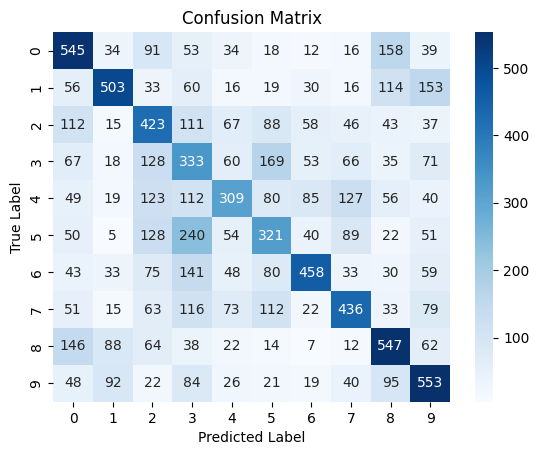

In [39]:
from sklearn.metrics import confusion_matrix       # Confusion matrix
cm = confusion_matrix(y_test, y_gmm_pca_hog_pred)
sns.heatmap(cm,annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")